In [219]:
import numpy as np
import pandas as pd
import scipy
import matplotlib.pyplot as plt, seaborn as sns

from sklearn.preprocessing import StandardScaler

from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.model_selection import StratifiedKFold, train_test_split, GridSearchCV

import librosa, librosa.display
import IPython.display as ipd

plt.rcParams['figure.figsize'] = (10, 3)

# Phân loại dựa trên các đặc trưng đã có sẵn

## Tập Huấn luyện (Train Set)

In [220]:
features_30_sec = pd.read_csv('example_features.csv')
features_3_sec = pd.read_csv('example_features_3_sec.csv')

data_each_song = features_30_sec

Chia các bài hát thành tập huấn luyện (train) và tập kiểm tra (test) sử dụng bộ dữ liệu bản 30 giây

In [221]:
# CHỮA LỖI: Đổi từ 'label' thành 'genre_label' cho khớp với file CSV của bạn
X = data_each_song.drop(columns=['genre_label'])
labels = data_each_song.loc[:, 'genre_label']

cat_y = pd.Categorical(labels)
y = pd.Series(cat_y.codes)

print("✅ Đã chia tách X và y thành công!")
print(f"Kích thước tập dữ liệu số X: {X.shape}")

✅ Đã chia tách X và y thành công!
Kích thước tập dữ liệu số X: (990, 61)


In [222]:
# train / test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, shuffle=True, random_state=123)

In [223]:
# songs to train
fn_train = np.sort(X_train.filename.values)

# songs to test
fn_test = np.sort(X_test.filename.values)

Chia 3 giây

In [224]:
data = features_3_sec

In [225]:
songs = []
for i in range(len(data)):
    split = data.filename[i].split('.')
    # CHỮA LỖI: Đổi split[3] thành split[2] cho khớp với số lượng khúc đã cắt
    songs.append(split[0] + '.' + split[1] + '.' + split[2])

data['songname'] = pd.Series(songs)
print("✅ Đã tạo cột 'songname' thành công!")
print(data['songname'].head()) # In thử 5 dòng đầu xem kết quả mượt mà chưa

✅ Đã tạo cột 'songname' thành công!
0    blues\blues.00000.0
1    blues\blues.00000.1
2    blues\blues.00000.2
3    blues\blues.00000.3
4    blues\blues.00000.4
Name: songname, dtype: str


In [226]:
song_data_ = []
for song in fn_train:
    song_data_.append(data[data.songname==song])
train_data = pd.concat(song_data_)

song_data_ = []
for song in fn_test:
    song_data_.append(data[data.songname==song])
test_data = pd.concat(song_data_)

In [231]:
X_train = train_data.select_dtypes(include=['number']).drop(columns=['length'], errors='ignore')
y_train = pd.Series(pd.Categorical(train_data.loc[:, 'genre_label']).codes)

X_test = test_data.select_dtypes(include=['number']).drop(columns=['length'], errors='ignore')
y_test = pd.Series(pd.Categorical(test_data.loc[:, 'genre_label']).codes)

print("✅ Đã sửa cách lấy cột đặc trưng thành công!")
print(f"Kích thước X_train thực tế: {X_train.shape[0]} hàng, {X_train.shape[1]} cột.")

✅ Đã sửa cách lấy cột đặc trưng thành công!
Kích thước X_train thực tế: 0 hàng, 59 cột.


In [230]:
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)

ValueError: Found array with 0 sample(s) (shape=(0, 59)) while a minimum of 1 is required by StandardScaler.

In [ ]:
y_train.value_counts()

Series([], Name: count, dtype: int64)

In [ ]:
y_test.value_counts()

Series([], Name: count, dtype: int64)

## Model

In [ ]:
svc = SVC(kernel='rbf')
rf = RandomForestClassifier()
# clf = AdaBoostClassifier()
# clf = GradientBoostingClassifier()
xgb = XGBClassifier(n_estimators=100)

**Hyperparameter tuning**

In [ ]:
param_grid1 = {'C': [10, 100], 
              'gamma': [0.1, 0.01, 0.001]} 
cv = StratifiedKFold(n_splits=3, shuffle=True)  
grid1 = GridSearchCV(svc, param_grid1, cv=cv, verbose = 1)
grid1.fit(X_train_scaled, y_train)
print(grid1.best_estimator_)

Fitting 3 folds for each of 6 candidates, totalling 18 fits


KeyboardInterrupt: 

In [ ]:
param_grid2 = {'n_estimators': [50, 100],
               'max_depth': [None, 6, 12]}
cv = StratifiedKFold(n_splits=3, shuffle=True)
grid2 = GridSearchCV(rf, param_grid2, cv=cv, verbose = 1)
grid2.fit(X_train, y_train)
print(grid2.best_estimator_)

Fitting 3 folds for each of 6 candidates, totalling 18 fits
RandomForestClassifier()


In [ ]:
param_grid3 = {'learning_rate': [0.01, 0.1, 0.3, 0.5]}
cv = StratifiedKFold(n_splits=3, shuffle=True)
grid3 = GridSearchCV(xgb, param_grid3, cv=cv, verbose = 1)
grid3.fit(X_train, y_train)
print(grid3.best_estimator_)

Fitting 3 folds for each of 4 candidates, totalling 12 fits
XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.3, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, ...)


**train**

In [ ]:
clf1 = grid1.best_estimator_
clf1.fit(X_train_scaled, y_train)

clf2 = grid2.best_estimator_
clf2.fit(X_train, y_train)

clf3 = grid3.best_estimator_
clf3.fit(X_train, y_train)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_metho

**predict**

In [ ]:
# for SVC
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

In [ ]:
y_true = y_test.copy()
y_pred1 = clf1.predict(X_test_scaled) # SVC
y_pred2 = clf2.predict(X_test)
y_pred3 = clf3.predict(X_test)

c:\Users\lequo\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but SVC was fitted without feature names
  warnings.warn(


## Results

SVM Accuracy:  0.9171717171717172
SVM F1:  0.917210138279495


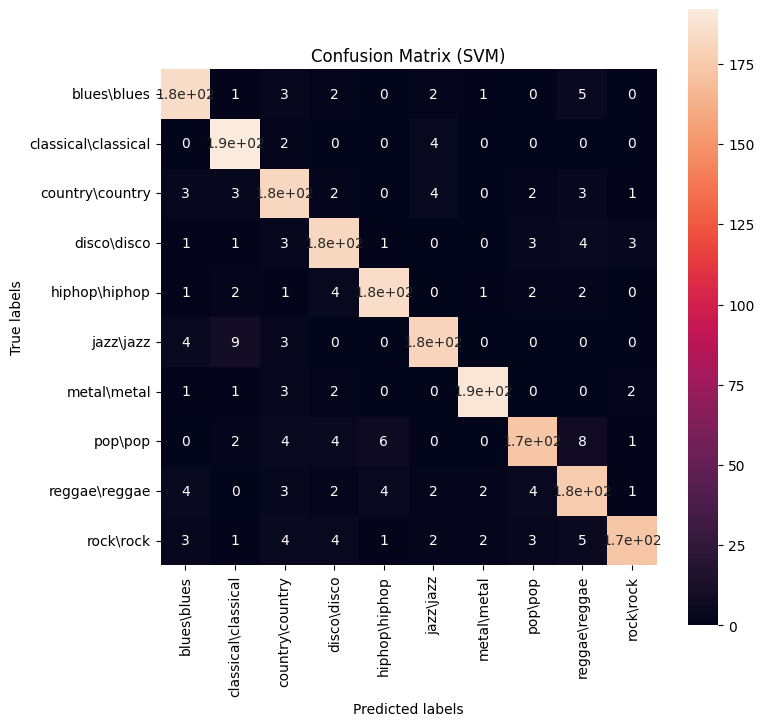

In [ ]:
print('SVM Accuracy: ', accuracy_score(y_true, y_pred1))
print('SVM F1: ', f1_score(y_true, y_pred1, average='macro'))

f,ax= plt.subplots(figsize=(8,8))
sns.heatmap(confusion_matrix(y_true, y_pred1), annot=True, square=True, 
            xticklabels=cat_y.categories, yticklabels=cat_y.categories, ax=ax)
ax.set_xlabel('Predicted labels')
ax.set_ylabel('True labels')
ax.set_title('Confusion Matrix (SVM)')
plt.show()

In [ ]:
print("SVC classification report:",'\n')
print(classification_report(y_true, y_pred1))
print(dict(zip(cat_y.categories, range(10))))

SVC classification report: 

              precision    recall  f1-score   support

           0       0.92      0.93      0.92       198
           1       0.91      0.97      0.94       198
           2       0.88      0.91      0.89       200
           3       0.90      0.92      0.91       198
           4       0.94      0.93      0.94       198
           5       0.93      0.92      0.92       196
           6       0.97      0.95      0.96       198
           7       0.93      0.87      0.90       198
           8       0.87      0.89      0.88       198
           9       0.96      0.87      0.91       198

    accuracy                           0.92      1980
   macro avg       0.92      0.92      0.92      1980
weighted avg       0.92      0.92      0.92      1980

{'blues\\blues': 0, 'classical\\classical': 1, 'country\\country': 2, 'disco\\disco': 3, 'hiphop\\hiphop': 4, 'jazz\\jazz': 5, 'metal\\metal': 6, 'pop\\pop': 7, 'reggae\\reggae': 8, 'rock\\rock': 9}


RF Accuracy:  0.8757575757575757
RF F1:  0.8753692224832648


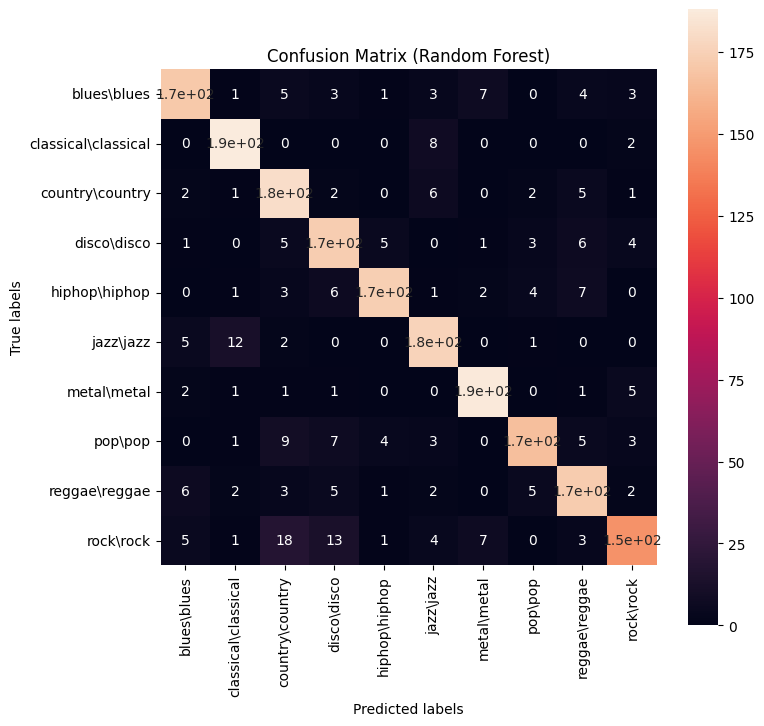

In [ ]:
print('RF Accuracy: ', accuracy_score(y_true, y_pred2))
print('RF F1: ', f1_score(y_true, y_pred2, average='macro'))

f,ax= plt.subplots(figsize=(8,8))
sns.heatmap(confusion_matrix(y_true, y_pred2), annot=True, square=True, 
            xticklabels=cat_y.categories, yticklabels=cat_y.categories, ax=ax)
ax.set_xlabel('Predicted labels')
ax.set_ylabel('True labels')
ax.set_title('Confusion Matrix (Random Forest)')
plt.show()

In [ ]:
print("RF classification report:",'\n')
print(classification_report(y_true, y_pred2))
print(dict(zip(cat_y.categories, range(10))))

RF classification report: 

              precision    recall  f1-score   support

           0       0.89      0.86      0.88       198
           1       0.90      0.95      0.93       198
           2       0.80      0.91      0.85       200
           3       0.82      0.87      0.85       198
           4       0.94      0.88      0.91       198
           5       0.87      0.90      0.88       196
           6       0.92      0.94      0.93       198
           7       0.92      0.84      0.88       198
           8       0.85      0.87      0.86       198
           9       0.88      0.74      0.80       198

    accuracy                           0.88      1980
   macro avg       0.88      0.88      0.88      1980
weighted avg       0.88      0.88      0.88      1980

{'blues\\blues': 0, 'classical\\classical': 1, 'country\\country': 2, 'disco\\disco': 3, 'hiphop\\hiphop': 4, 'jazz\\jazz': 5, 'metal\\metal': 6, 'pop\\pop': 7, 'reggae\\reggae': 8, 'rock\\rock': 9}


XGB Accuracy:  0.9121212121212121
XGB F1:  0.9121378675949611


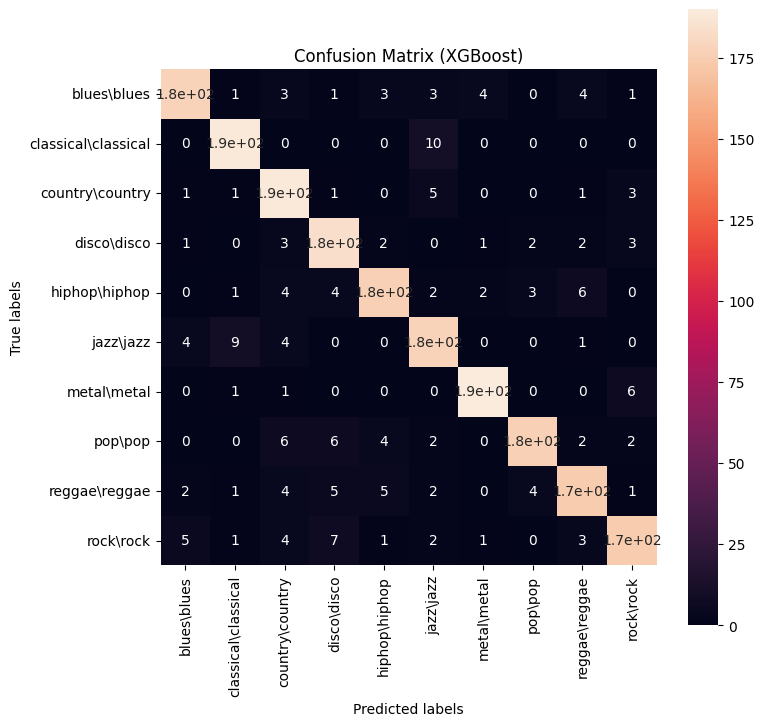

In [ ]:
print('XGB Accuracy: ', accuracy_score(y_true, y_pred3))
print('XGB F1: ', f1_score(y_true, y_pred3, average='macro'))

f,ax= plt.subplots(figsize=(8,8))
sns.heatmap(confusion_matrix(y_true, y_pred3), annot=True, square=True, 
            xticklabels=cat_y.categories, yticklabels=cat_y.categories, ax=ax)
ax.set_xlabel('Predicted labels')
ax.set_ylabel('True labels')
ax.set_title('Confusion Matrix (XGBoost)')
plt.show()

In [ ]:
print("XGB classification report:",'\n')
print(classification_report(y_true, y_pred3))
print(dict(zip(cat_y.categories, range(10))))

XGB classification report: 

              precision    recall  f1-score   support

           0       0.93      0.90      0.92       198
           1       0.93      0.95      0.94       198
           2       0.87      0.94      0.90       200
           3       0.88      0.93      0.91       198
           4       0.92      0.89      0.90       198
           5       0.87      0.91      0.89       196
           6       0.96      0.96      0.96       198
           7       0.95      0.89      0.92       198
           8       0.90      0.88      0.89       198
           9       0.92      0.88      0.90       198

    accuracy                           0.91      1980
   macro avg       0.91      0.91      0.91      1980
weighted avg       0.91      0.91      0.91      1980

{'blues\\blues': 0, 'classical\\classical': 1, 'country\\country': 2, 'disco\\disco': 3, 'hiphop\\hiphop': 4, 'jazz\\jazz': 5, 'metal\\metal': 6, 'pop\\pop': 7, 'reggae\\reggae': 8, 'rock\\rock': 9}


## interpretation

- As a result of checking the performance of the classifier by targeting the genre for 3 seconds(1/10 part) of each song, it can be seen that the accuracy and F1 score are about 69%. XGboost shows highest performace scores among the models

- As you can see in the confusion matrix some specific genres are misclassified. Let's check this case by case.

- First of all, let's look at which genre was most mis-predicted for each genre. (RF based)
     - **Blues**: Country 31, Metal 23, etc.
     - **Classical** (high score - well classified): Jazz 12
     - **Country**: Blues 35, Rock 18, etc.
     - **Disco**: Hip Hop 55, Metal 31, Rock 31, etc.
     - **Hip Hop**: Pop 32, Reggae 19
     - **Jazz**: Classic 23
     - **Metal**: Blues 17, Rock 14, etc.
     - **Pop**: Hip Hop 30, Disco 17, etc.
     - **Reggae**: Country 24, Hip Hop 23, etc.
     - **Rock** (low score): Metal 69, Disco 4, etc.
    
- Looking at the misclassified genres, we can see the pairs: **blues-country, classical-jazz, disco-hip-hop, pop-hip-hop, hip-hop-reggae, metal-rock**. Intuitively, it is mainly genre pairs that are generally thought to have genre similarities (but there are some pairs that are not; **metal-blues, raggae-country**; maybe they have some similar musical characteristics)

- In other words, it can be inferred that the feature based on the given audio content has some musical characteristic information, similar to the genre artificially classified by people.

## feature importance

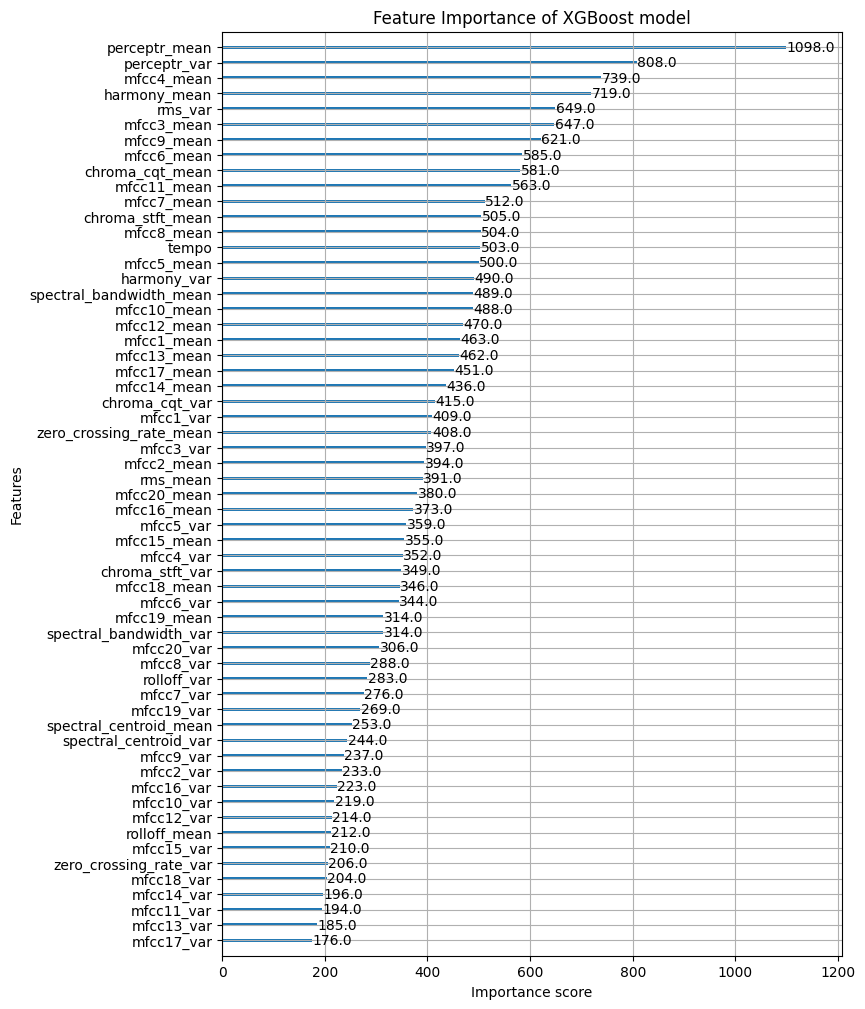

In [ ]:
fig, ax = plt.subplots(figsize=(8,12))
from xgboost import plot_importance
plot_importance(clf3, ax=ax, title='Feature Importance of XGBoost model')
plt.show()

- hamornic, percussive time series features have high importance.
- spectral features have relatively low importance.
- mfcc features variance have very low importance.

## without variance features

- excluding variances
- for simplicity only using xgboost with default parameters

In [ ]:
feat_names = [col for col in train_data.columns if 'mean' in col] # only mean data

In [ ]:
X_train = train_data.loc[:,feat_names]
y_train = pd.Series(pd.Categorical(train_data.loc[:,'label']).codes)

X_test = test_data.loc[:,feat_names]
y_test = pd.Series(pd.Categorical(test_data.loc[:,'label']).codes)

✅ Đã tách dữ liệu thành công!
Tập Train: X_train có 0 mẫu, 60 đặc trưng.
Tập Test: X_test có 0 mẫu.


In [ ]:
xgb = XGBClassifier(n_estimators=100, learning_rate=0.5)
xgb.fit(X_train, y_train)

c:\Users\lequo\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\xgboost\training.py:200: UserWarning: [17:12:48] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:56: Empty dataset at worker: 0
  bst.update(dtrain, iteration=i, fobj=obj)


,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_meth

In [ ]:
y_true = y_test.copy()
y_pred4 = xgb.predict(X_test)

In [ ]:
print('XGB Accuracy: ', accuracy_score(y_true, y_pred4))
print('XGB F1: ', f1_score(y_true, y_pred4, average='macro'))

f,ax= plt.subplots(figsize=(8,8))
sns.heatmap(confusion_matrix(y_true, y_pred4), annot=True, square=True, 
            xticklabels=cat_y.categories, yticklabels=cat_y.categories, ax=ax)
ax.set_xlabel('Predicted labels')
ax.set_ylabel('True labels')
ax.set_title('Confusion Matrix (XGBoost)')
plt.show()

🔥 Sửa lỗi thành công! Tập X_test hiện tại đã có: 1980 hàng dữ liệu.


- lower scores but not that bad

ValueError: Booster.get_score() results in empty.  This maybe caused by having all trees as decision dumps.

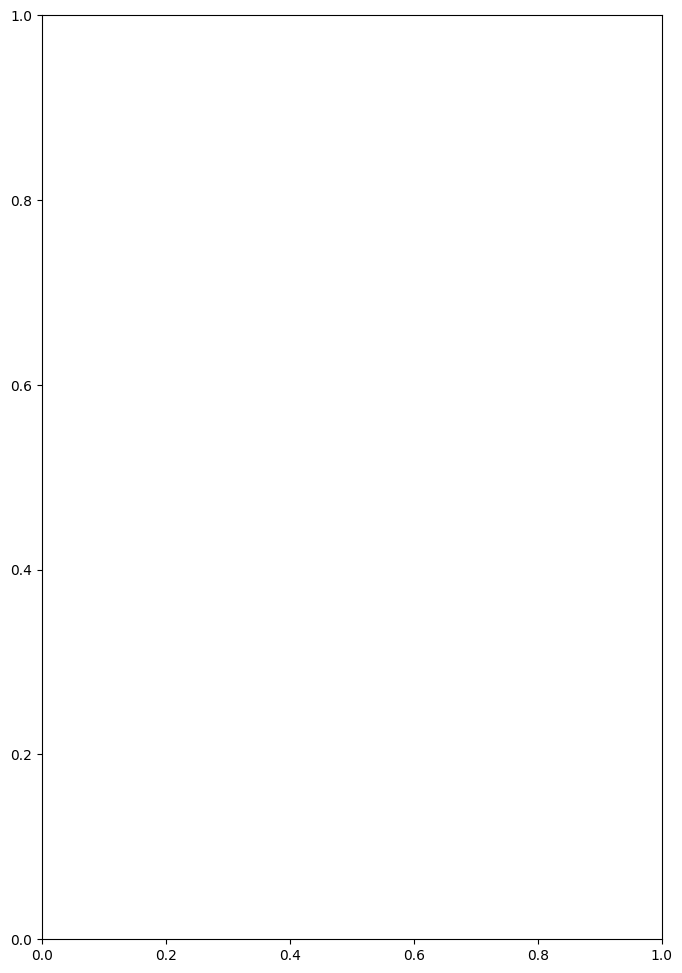

In [ ]:
fig, ax = plt.subplots(figsize=(8,12))
plot_importance(xgb, ax=ax, title='Feature Importance of XGBoost model')
plt.show()

In [ ]:
import os
import librosa
import numpy as np
import pandas as pd

def predict_genre_of_file(song_path, model, scaler, feature_names, categories):
    try:
        # 1. Tải file âm thanh (30 giây)
        y, sr = librosa.load(song_path, duration=3.0) 
        # 2. Trích xuất toàn bộ các đặc trưng nâng cao y hệt file feature_extraction.py của bạn
        tempo, _ = librosa.beat.beat_track(y=y, sr=sr)
        chroma_stft = librosa.feature.chroma_stft(y=y, sr=sr)
        rmse = librosa.feature.rms(y=y)
        spec_cent = librosa.feature.spectral_centroid(y=y, sr=sr)
        spec_bw = librosa.feature.spectral_bandwidth(y=y, sr=sr)
        rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr)
        zcr = librosa.feature.zero_crossing_rate(y=y)
        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=20)
        # Thêm các đặc trưng nâng cao gây lỗi lúc nãy
        harmony_wave = librosa.effects.harmonic(y)
        percussive_wave = librosa.effects.percussive(y)
        chroma_cqt = librosa.feature.chroma_cqt(y=y, sr=sr)
        features = {
            'length': 66149,
            'chroma_stft_mean': np.mean(chroma_stft), 'chroma_stft_var': np.var(chroma_stft),
            'rms_mean': np.mean(rmse), 'rms_var': np.var(rmse),
            'spectral_centroid_mean': np.mean(spec_cent), 'spectral_centroid_var': np.var(spec_cent),
            'spectral_bandwidth_mean': np.mean(spec_bw), 'spectral_bandwidth_var': np.var(spec_bw),
            'rolloff_mean': np.mean(rolloff), 'rolloff_var': np.var(rolloff),
            'zero_crossing_rate_mean': np.mean(zcr), 'zero_crossing_rate_var': np.var(zcr),
            'harmony_mean': np.mean(harmony_wave), 'harmony_var': np.var(harmony_wave),
            'perceptr_mean': np.mean(percussive_wave), 'perceptr_var': np.var(percussive_wave),
            'tempo': tempo[0] if isinstance(tempo, (list, np.ndarray)) else tempo,
            'chroma_cqt_mean': np.mean(chroma_cqt), 'chroma_cqt_var': np.var(chroma_cqt)
        }
        for i in range(20):
            features[f'mfcc{i+1}_mean'] = np.mean(mfcc[i])
            features[f'mfcc{i+1}_var'] = np.var(mfcc[i])
        # 3. Ép đúng định dạng cột của tập train và chuẩn hóa
        df_song = pd.DataFrame([features])[feature_names]
        df_song_scaled = scaler.transform(df_song)
       

        # 4. Dự đoán thể loại
        pred_code = model.predict(df_song_scaled)[0]
        return categories[pred_code].upper()
    except Exception as e:
        return f"LỖI (Quá trình trích xuất thất bại: {e})"

# --- ĐOẠN QUÉT THƯ MỤC MUSIC_TEST ---
FOLDER_TEST = "music_test"
if not os.path.exists(FOLDER_TEST):
    print(f"❌ Bạn chưa tạo folder '{FOLDER_TEST}' hoặc để sai vị trí rồi!")
else:
    valid_extensions = ('.wav', '.mp3', '.m4a', '.flac')
    all_files = [f for f in os.listdir(FOLDER_TEST) if f.lower().endswith(valid_extensions)]
    if len(all_files) == 0:
        print(f"📁 Folder '{FOLDER_TEST}' đang trống rỗng hoặc không có file nhạc phù hợp.")
    else:
        print(f"🚀 Tìm thấy {len(all_files)} file nhạc trong thư mục '{FOLDER_TEST}'. Đang tiến hành chấm điểm...")
        print("-" * 60)
        for file_name in all_files:
            full_path = os.path.join(FOLDER_TEST, file_name)
            # Sử dụng mô hình SVM (clf1) để dự đoán
            prediction = predict_genre_of_file(
                song_path=full_path,
                model=clf1_3s,
                scaler=scaler_3s,
                feature_names=X_train_3s.columns,
                categories=cat_y_3s.categories
            )
            print(f"🎵 {file_name} ---> 🤖 AI đoán: {prediction}")
        print("-" * 60)
        print("🎉 Đã quét xong toàn bộ danh sách nhạc thành công!")

🚀 Tìm thấy 11 file nhạc trong thư mục 'music_test'. Đang tiến hành chấm điểm...
------------------------------------------------------------


NameError: name 'clf1_3s' is not defined